In [1]:
import matplotlib.pyplot as plt
import sys
sys.path.append('../../Codes/library/')

import scipy.special as sc
from funcs import*

plt.rcParams['text.usetex'] = True
Text_files_path = '/Users/robertomorantovar/Dropbox/Research/Immune_system/'
output_plot = '/Users/robertomorantovar/Dropbox/My_Documents/Science/Projects/Immune_System/_Repository/Figures/exponential_proofreading/data/mesin2020/entropy/'
os.makedirs(output_plot, exist_ok=True)

%autosave 60

Autosaving every 60 seconds


[ 1  2  3  4  5  6  7  8  9 10]
11 121 52
6 36 45
10 100 70
9 81 74
5 25 55
6 36 62
3 9 63
6 36 49
10 100 93
6 36 104
Mean entropy: r$4.0$


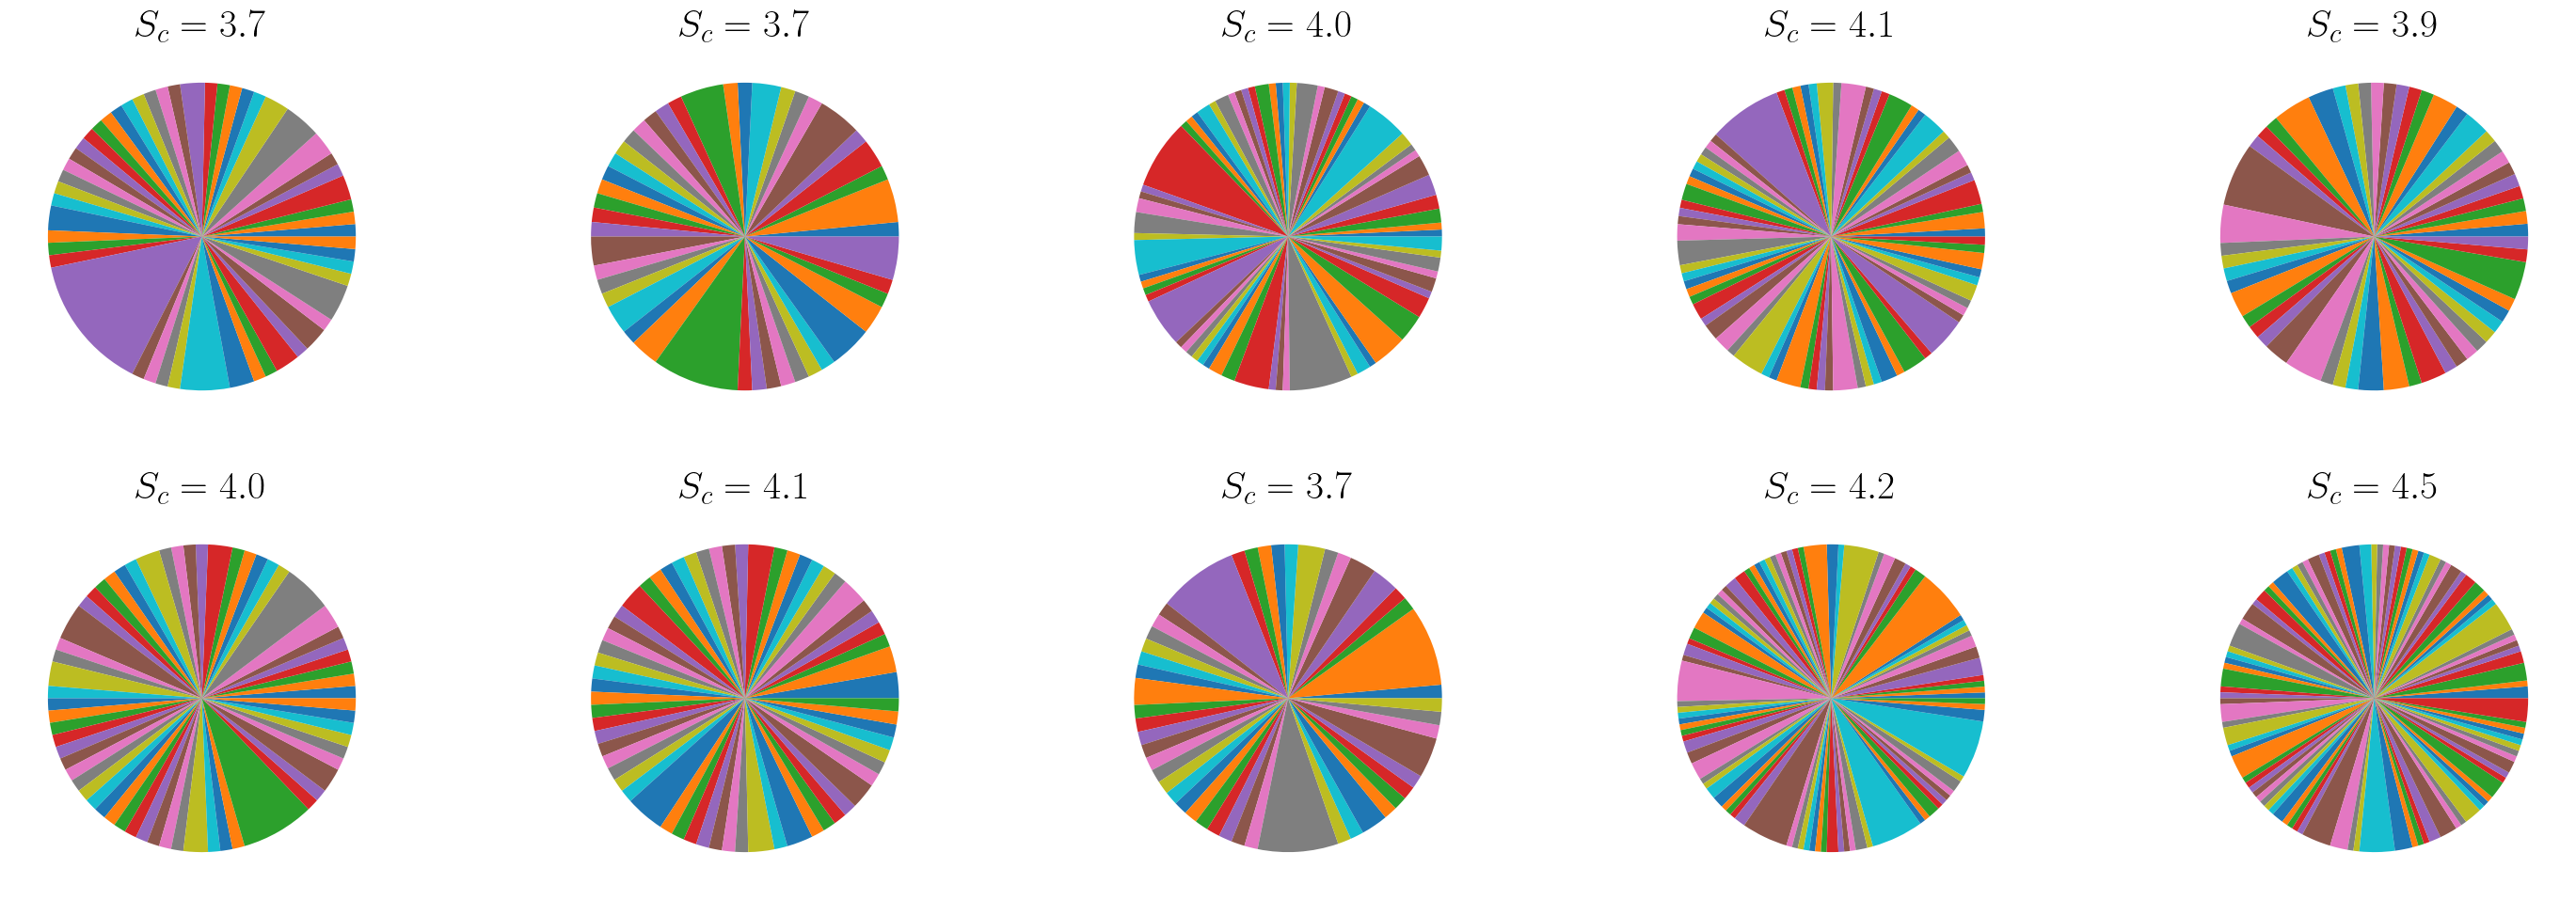

In [2]:
size_dict = defaultdict(list)
# Load primary data
data_primary = pd.read_excel(Text_files_path + "exponential_proofreading/data/mesin2020/1-s2.0-S0092867419313170-mmc1.xlsx", sheet_name = 'Photoactivation CGG', header = 1)
data_primary = data_primary[(data_primary['Figure']==1)]
data_primary_grouped = data_primary.groupby(['Mouse', 'V', 'J', 'D']).size().reset_index(name='count')
# data_primary_grouped = data_primary.groupby(['Mouse', 'CDR3:']).size().reset_index(name='count')
# data_primary_grouped = data_primary.groupby(['Mouse', 'Sequence']).size().reset_index(name='count')
mice = data_primary_grouped['Mouse'].unique()
print(mice)
fig, ax = plt.subplots(2, 5, figsize = (30, 10), gridspec_kw={'left':0.02, 'right':.95, 'bottom':.05, 'top': 0.95}, edgecolor = 'black')
S01_data = np.array([])
S_primary = np.array([])
CS_primary = np.array([])
L_act = np.array([])
for i, mouse in enumerate(mice):
    data_mouse = data_primary_grouped.loc[data_primary_grouped['Mouse']==mouse]
    counts = data_mouse['count'].to_numpy()
    size_dict['response'].append('primary')
    size_dict['N1'].append(np.max(counts))
    size_dict['L_act'].append(np.size(counts))
    size_dict['barN'].append(np.sum(counts))
    print(np.max(counts), np.max(counts)**2, len(counts))
    CS_primary = np.append(CS_primary, counts)
    N = np.sum(counts)
    S_i = -np.sum((counts/N)*np.log((counts/N)))
    S_primary = np.append(S_primary, S_i)
    L_act = np.append(L_act, np.size(counts))
    S01_data = np.append(S01_data, np.log(L_act[-1]))
    if S_i != 0:
        ax[i//5, i%5].pie(counts)
        ax[i//5, i%5].set_title(r'$S_c=%.1f$'%(S_i), fontsize = 30)
    else:
        ax[i//5, i%5].axis('off')
        ax[i//5, i%5].text(x = .1, y = .6, s = r'$\bar S_c = %.1f \pm %.1f$'%(np.mean(S_primary), np.sqrt(np.var(S_primary))), fontsize = 30)
# fig.suptitle(r'$\bar S_c = %.1f \pm %.1f$'%(np.mean(S_primary), np.sqrt(np.var(S_primary))), fontsize = 30)
print('Mean entropy: r$%.1f$'%(np.mean(S_primary)))


Mean entropy: r$1.8$
Mean entropy: r$2.4$
10


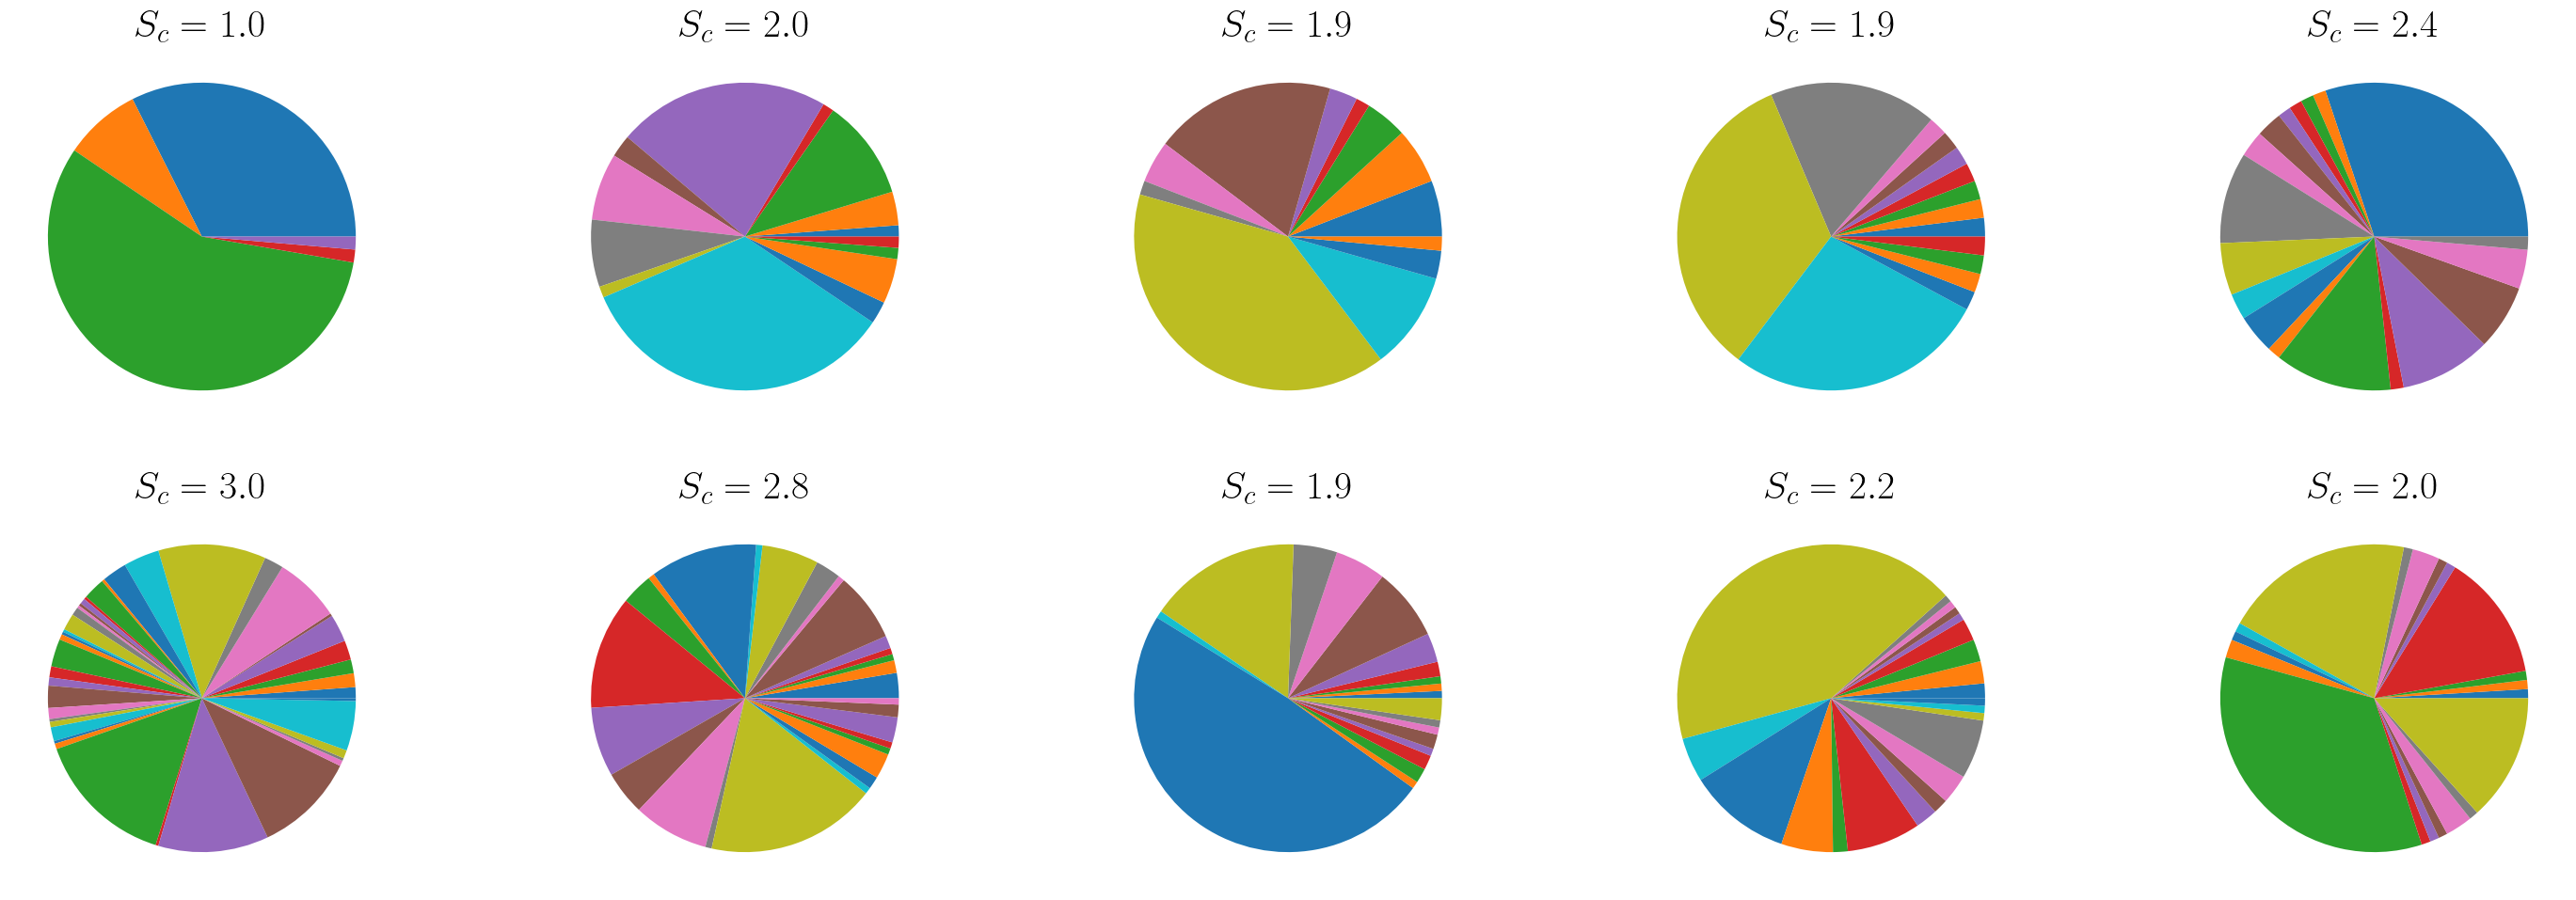

In [3]:
# Load recall data
data_memory = pd.read_excel(Text_files_path + "exponential_proofreading/data/mesin2020/1-s2.0-S0092867419313170-mmc1.xlsx", sheet_name = 'Fate-mapping CGG', header = 1)
figures = ['4A', '4C-H']
S02_data = np.array([])
S_memory = np.array([])
CS_memory = np.array([])
fig, ax = plt.subplots(2, 5, figsize = (30, 10), gridspec_kw={'left':0.02, 'right':.95, 'bottom':.05, 'top': 0.95}, edgecolor = 'black')
for i_fig, fig in enumerate(figures):
	data_memory_fig = data_memory[(data_memory['Figure']==fig)]
	# data_memory_fig = data_memory_fig[data_memory_fig['Phenotype']=='GC + fm']
	data_memory_grouped = data_memory_fig.groupby(['Mouse', 'V', 'J', 'D']).size().reset_index(name='count')
	# data_memory_grouped = data_memory_fig.groupby(['Mouse', 'CDR3:']).size().reset_index(name='count')
	# data_memory_grouped = data_memory_fig.groupby(['Mouse', 'Sequence']).size().reset_index(name='count')
	mice = data_memory_grouped['Mouse'].unique()
	S_memory_fig = np.array([])
	L_act = np.array([])
	for i, mouse in enumerate(mice):
		data_mouse = data_memory_grouped.loc[data_memory_grouped['Mouse']==mouse]
		counts = data_mouse['count'].to_numpy()
		N = np.sum(counts)
		size_dict['response'].append('memory')
		size_dict['N1'].append(np.max(counts))
		size_dict['L_act'].append(np.size(counts))
		size_dict['barN'].append(np.sum(counts))
		S_i = -np.sum((counts/N)*np.log((counts/N)))
		S_memory_fig = np.append(S_memory_fig, S_i)
		S_memory = np.append(S_memory, S_i)
		CS_memory = np.append(CS_memory, counts)
		L_act = np.append(L_act, np.size(counts))
		S02_data = np.append(S02_data, np.log(L_act[-1]))
		if S_i != 0:
			ax[i_fig, i%5].pie(counts)
			ax[i_fig, i%5].set_title(r'$S_c=%.1f$'%(S_i), fontsize = 30)
		else:
			ax[i_fig, i%5].axis('off')
			ax[i_fig, i%5].text(x = .1, y = .6, s = r'$\bar S_c = %.1f \pm %.1f$'%(np.mean(S_memory_fig), np.sqrt(np.var(S_memory_fig))), fontsize = 30)
	# fig.suptitle(r'$\bar S_c = %.1f \pm %.1f$'%(np.mean(S_memory_fig), np.sqrt(np.var(S_memory_fig))), fontsize = 30)
	print('Mean entropy: r$%.1f$'%(np.mean(S_memory_fig)))
print(len(S_memory))


['GC' 'fm' 'M' 'PC']
Mean entropy: r$3.9$
Mean entropy: r$2.9$
8


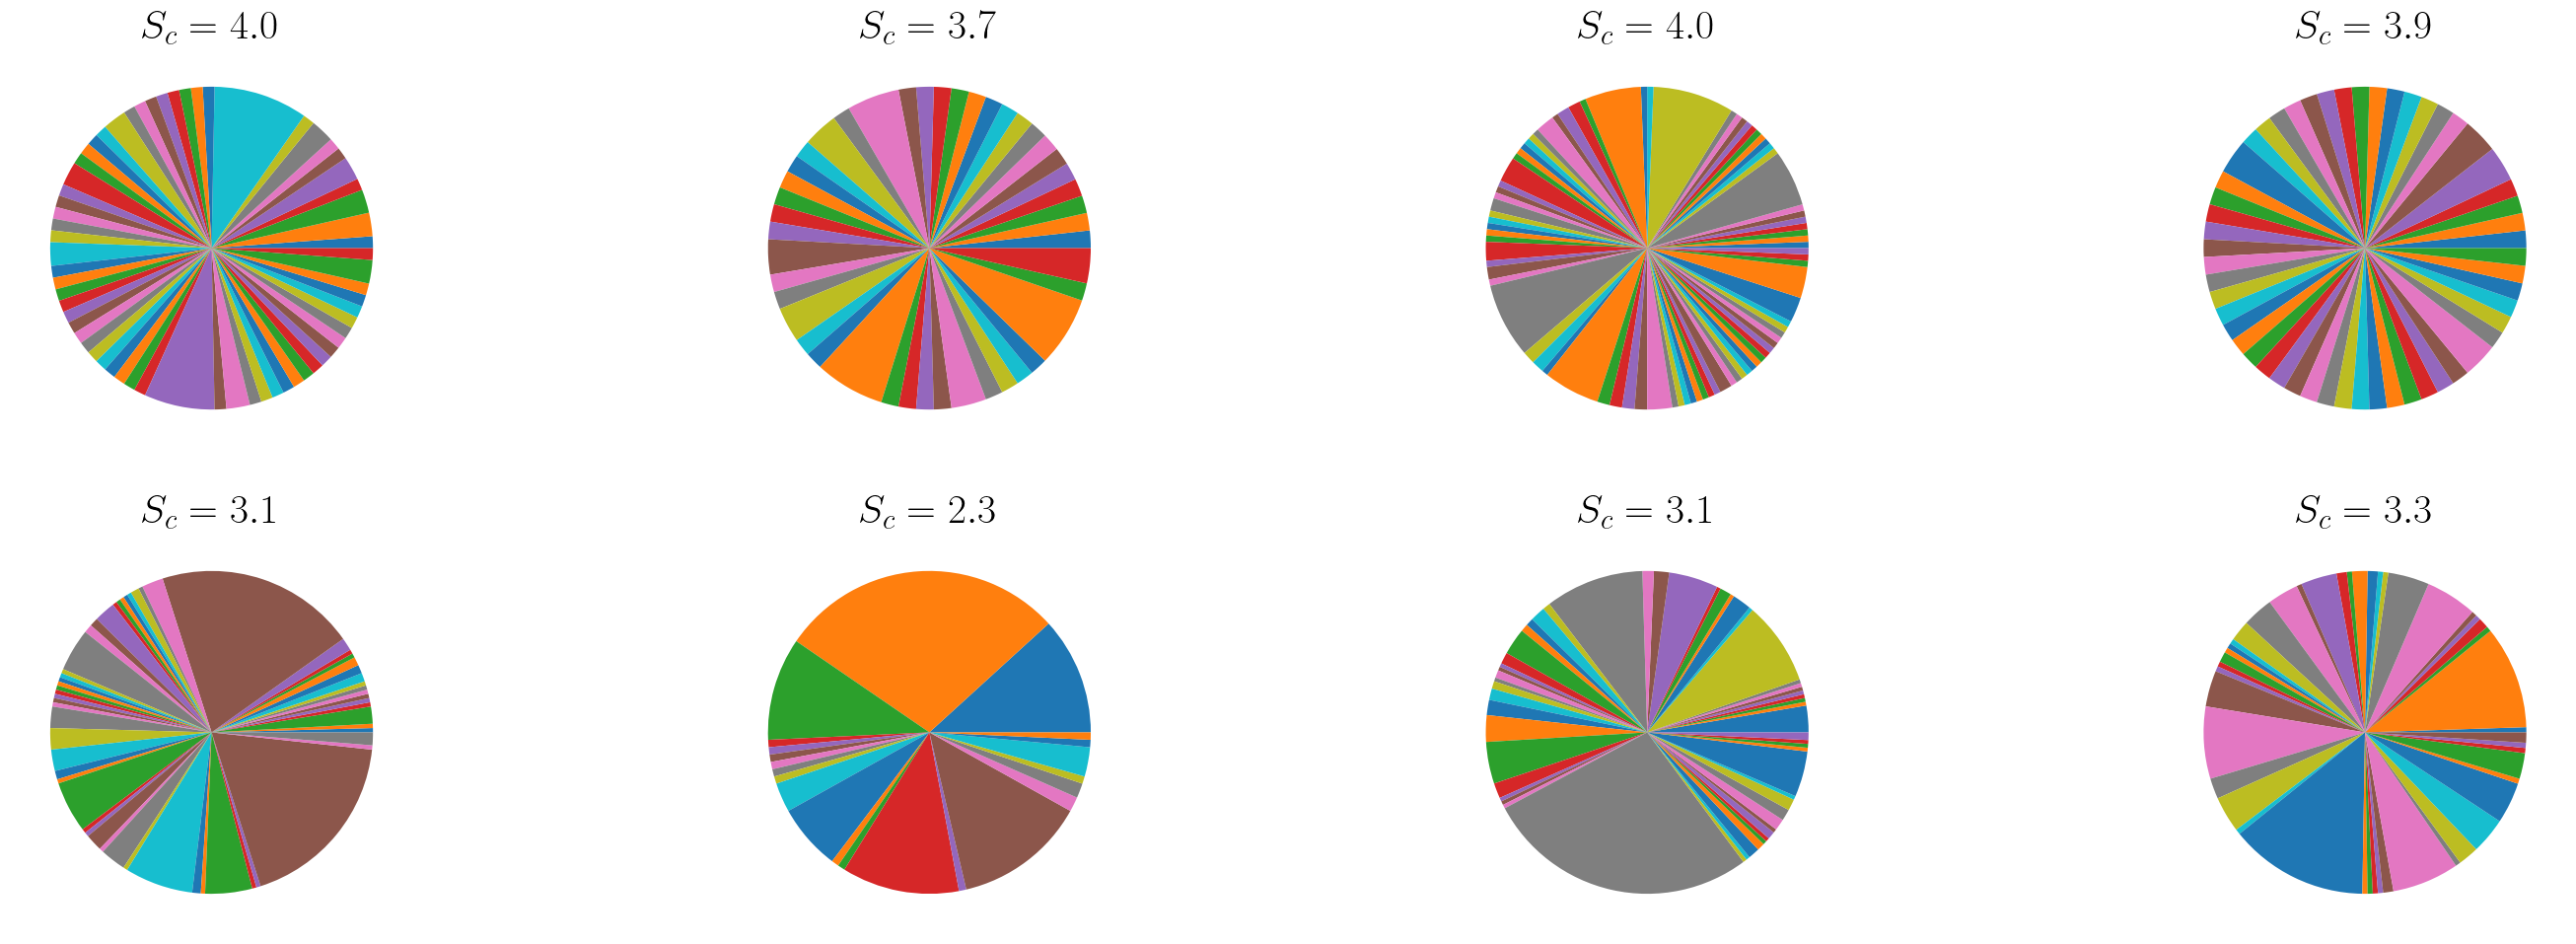

In [ ]:
# Load Influenza data
data_memory = pd.read_excel(Text_files_path + "exponential_proofreading/data/mesin2020/1-s2.0-S0092867419313170-mmc1.xlsx", sheet_name = 'Influenza', header = 2)
S02_data = np.array([])
S_memory = np.array([])
CS_memory = np.array([])
fig, ax = plt.subplots(2, 4, figsize = (30, 10), gridspec_kw={'left':0.02, 'right':.95, 'bottom':.05, 'top': 0.95}, edgecolor = 'black')
phenotypes = data_memory['Sort2'].unique()
print(phenotypes)
for i_ph, ph in enumerate(phenotypes[:2]):
	data_memory_ph = data_memory[data_memory['Sort2']==ph]
	data_memory_grouped = data_memory_ph.groupby(['Experiment / Mouse', 'V', 'J', 'D']).size().reset_index(name='count')
	# data_memory_grouped = data_memory_ph.groupby(['Experiment / Mouse', 'CDR3:']).size().reset_index(name='count')
	# data_memory_grouped = data_memory_ph.groupby(['Experiment / Mouse', 'Sequence']).size().reset_index(name='count')
	mice = data_memory_grouped['Experiment / Mouse'].unique()
	S_memory_fig = np.array([])
	L_act = np.array([])
	for i, mouse in enumerate(mice):
		data_mouse = data_memory_grouped.loc[data_memory_grouped['Experiment / Mouse']==mouse]
		counts = data_mouse['count'].to_numpy()
		N = np.sum(counts)
		size_dict['response'].append(ph)
		size_dict['N1'].append(np.max(counts))
		size_dict['L_act'].append(np.size(counts))
		size_dict['barN'].append(np.sum(counts))
		S_i = -np.sum((counts/N)*np.log((counts/N)))
		S_memory_fig = np.append(S_memory_fig, S_i)
		S_memory = np.append(S_memory, S_i)
		CS_memory = np.append(CS_memory, counts)
		L_act = np.append(L_act, np.size(counts))
		S02_data = np.append(S02_data, np.log(L_act[-1]))
		if S_i != 0:
			ax[i_ph, i%4].pie(counts)
			ax[i_ph, i%4].set_title(r'$S_c=%.1f$'%(S_i), fontsize = 30)
		else:
			ax[i_ph, i%4].axis('off')
			ax[i_ph, i%4].text(x = .1, y = .6, s = r'$\bar S_c = %.1f \pm %.1f$'%(np.mean(S_memory_fig), np.sqrt(np.var(S_memory_fig))), fontsize = 30)
	# fig.suptitle(r'$\bar S_c = %.1f \pm %.1f$'%(np.mean(S_memory_fig), np.sqrt(np.var(S_memory_fig))), fontsize = 30)
	print('Mean entropy: r$%.1f$'%(np.mean(S_memory_fig)))
print(len(S_memory))

In [5]:
zeta_primary_1 = 0.52
zeta_primary_flu = 0.49
zeta_memory_1 = 1.25
zeta_memory_flu = 1.1

/var/folders/zb/94w9fjpd0_s_68nft_zfybt80000gp/T/ipykernel_4211/158706995.py:3: UserWarning: The palette list has more values (7) than needed (4), which may not be intended.
  sns.scatterplot(data = size_results, x = 'N1', y = 'L_act', hue = 'response', ax = ax, s = 100, markers=['o', 'o', '^', '^', '^', '^', '^'], palette = [my_blue, my_red, 'purple', 'darkorange', 'purple', 'brown', 'pink'], edgecolors = 'black', alpha = 0.8)


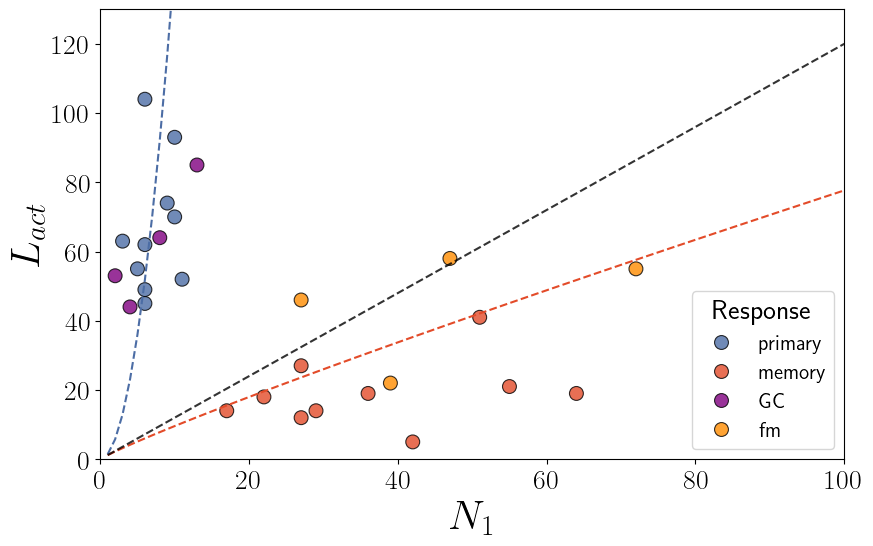

In [6]:
size_results = pd.DataFrame(size_dict)
fig, ax = plt.subplots(figsize = (8, 5), gridspec_kw={'left':0.02, 'right':.95, 'bottom':.05, 'top': 0.95}, edgecolor = 'black')
sns.scatterplot(data = size_results, x = 'N1', y = 'L_act', hue = 'response', ax = ax, s = 100, markers=['o', 'o', '^', '^', '^', '^', '^'], palette = [my_blue, my_red, 'purple', 'darkorange', 'purple', 'brown', 'pink'], edgecolors = 'black', alpha = 0.8)
ax.plot(np.linspace(1, 100, 100), (np.linspace(1, 100, 100)*1.2)**(1/1.1), color = my_red, linestyle = '--')
ax.plot(np.linspace(1, 100, 100), (np.linspace(1, 100, 100)*1.2)**(1/0.5), color = my_blue, linestyle = '--')
ax.plot(np.linspace(1, 100, 100), (np.linspace(1, 100, 100)*1.2)**(1), color = 'k', linestyle = '--', alpha = .8)
ax.set_xlabel(r'$N_1$', fontsize = 30)
ax.set_ylabel(r'$L_{act}$', fontsize = 30)
ax.set_ylim(bottom=0, top = 130)
ax.set_xlim(left=0, right = 100)
ax.tick_params(labelsize = 20)
# ax.set_yscale('log')
# ax.set_xscale('log')
ax.legend(title = 'Response', title_fontsize = 20, fontsize = 15, loc = 0)
fig.savefig(output_plot + 'size_scaling.pdf', bbox_inches = 'tight')

/var/folders/zb/94w9fjpd0_s_68nft_zfybt80000gp/T/ipykernel_88238/1385441230.py:3: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.scatterplot(data = size_results, x = 'L_act', y = 'N1', hue = 'response', ax = ax, s = 100, markers=['o', 'o', '^', '^', '^', '^', '^'], palette = [my_red, my_blue, 'darkorange', 'purple', 'darkorange', 'purple', 'brown', 'pink'], edgecolors = 'black', alpha = 0.8)


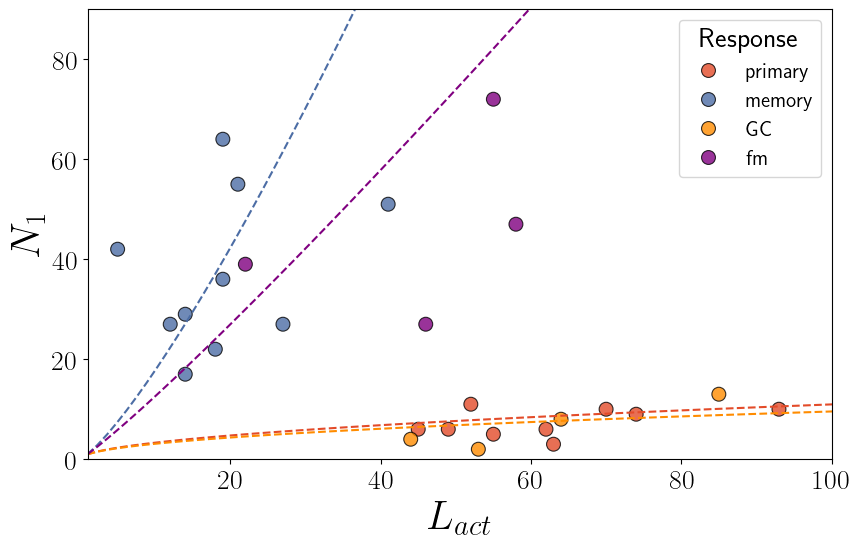

In [93]:
size_results = pd.DataFrame(size_dict)
fig, ax = plt.subplots(figsize = (8, 5), gridspec_kw={'left':0.02, 'right':.95, 'bottom':.05, 'top': 0.95}, edgecolor = 'black')
sns.scatterplot(data = size_results, x = 'L_act', y = 'N1', hue = 'response', ax = ax, s = 100, markers=['o', 'o', '^', '^', '^', '^', '^'], palette = [my_red, my_blue, 'darkorange', 'purple', 'darkorange', 'purple', 'brown', 'pink'], edgecolors = 'black', alpha = 0.8)
ax.plot(np.linspace(1, 130, 100), (np.linspace(1, 130, 100)*1.0)**(zeta_primary_1), color = my_red, linestyle = '--')
ax.plot(np.linspace(1, 130, 100), (np.linspace(1, 130, 100)*1.0)**(zeta_memory_1), color = my_blue, linestyle = '--')
ax.plot(np.linspace(1, 130, 100), (np.linspace(1, 130, 100)*1.0)**(zeta_primary_flu), color = 'darkorange', linestyle = '--')
ax.plot(np.linspace(1, 130, 100), (np.linspace(1, 130, 100)*1.0)**(zeta_memory_flu), color = 'purple', linestyle = '--')
# ax.plot(np.linspace(1, 130, 100), (np.linspace(1, 130, 100)*1.0)**(1), color = 'k', linestyle = '--', alpha = .8)
ax.set_xlabel(r'$L_{act}$', fontsize = 30)
ax.set_ylabel(r'$N_1$', fontsize = 30)
ax.set_ylim(bottom=0, top = 90)
ax.set_xlim(left=1, right = 100)
ax.tick_params(labelsize = 20)
# ax.set_yscale('log')
# ax.set_xscale('log')
ax.legend(title = 'Response', title_fontsize = 20, fontsize = 15, loc = 0)
fig.savefig(output_plot + 'size_scaling_1.pdf', bbox_inches = 'tight')

/var/folders/zb/94w9fjpd0_s_68nft_zfybt80000gp/T/ipykernel_4211/1274596608.py:2: UserWarning: The palette list has more values (7) than needed (4), which may not be intended.
  sns.scatterplot(data = size_results, x = 'barN', y = 'L_act', hue = 'response', ax = ax, s = 100, markers=['o', 'o', '^', '^', '^', '^', '^'], palette = [my_red, my_blue, 'darkorange', 'purple', 'purple', 'brown', 'pink'], edgecolors = 'black', alpha = 0.8)


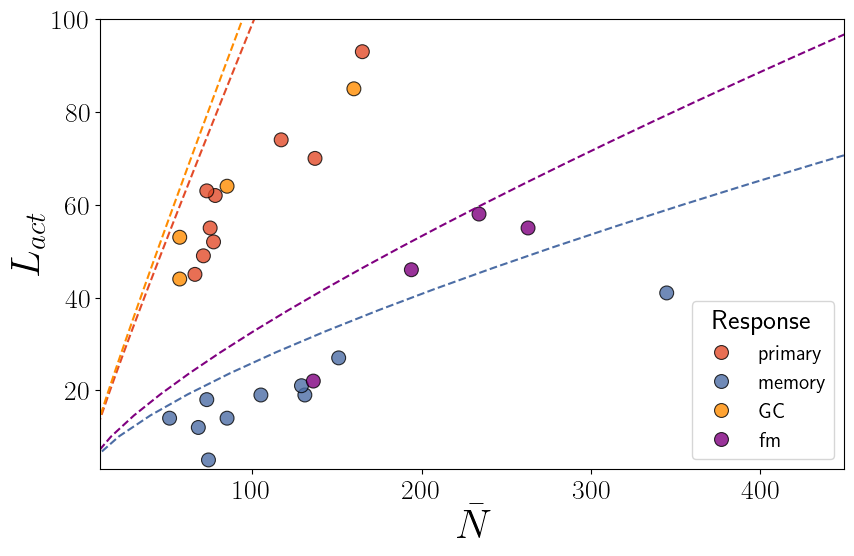

In [ ]:
fig, ax = plt.subplots(figsize = (8, 5), gridspec_kw={'left':0.02, 'right':.95, 'bottom':.05, 'top': 0.95}, edgecolor = 'black')
sns.scatterplot(data = size_results, x = 'barN', y = 'L_act', hue = 'response', ax = ax, s = 100, markers=['o', 'o', '^', '^', '^', '^', '^'], palette = [my_red, my_blue, 'darkorange', 'purple', 'purple', 'brown', 'pink'], edgecolors = 'black', alpha = 0.8)

# ax.plot(np.linspace(1, 150, 100), (np.linspace(1, 150, 100))/(1-zeta_primary_1), color = my_red, linestyle = '--')
# ax.plot(np.linspace(1, 150, 100), (np.linspace(1, 150, 100))**(zeta_memory_1)/(zeta_memory_1-1), color = my_blue, linestyle = '--')
# ax.plot(np.linspace(1, 150, 100), (np.linspace(1, 150, 100))/(1-zeta_primary_flu), color = 'darkorange', linestyle = '--')
# ax.plot(np.linspace(1, 150, 100), (np.linspace(1, 150, 100))**(zeta_memory_flu)/(zeta_memory_flu-1), color = 'purple', linestyle = '--')

ax.plot((np.linspace(1, 450, 100))**(zeta_primary_1)/(1-zeta_primary_1)*((np.linspace(1, 150, 100))**(1-zeta_primary_1)-1), np.linspace(1, 450, 100), color = my_red, linestyle = '--')
ax.plot((np.linspace(1, 450, 100))**(zeta_memory_1)/(1-zeta_memory_1)*((np.linspace(1, 150, 100))**(1-zeta_memory_1)-1), np.linspace(1, 450, 100), color = my_blue, linestyle = '--')
ax.plot((np.linspace(1, 450, 100))**(zeta_primary_flu)/(1-zeta_primary_flu)*((np.linspace(1, 150, 100))**(1-zeta_primary_flu)-1), np.linspace(1, 450, 100), color = 'darkorange', linestyle = '--')
ax.plot((np.linspace(1, 450, 100))**(zeta_memory_flu)/(1-zeta_memory_flu)*((np.linspace(1, 150, 100))**(1-zeta_memory_flu)-1), np.linspace(1, 450, 100), color = 'purple', linestyle = '--')

ax.set_xlabel(r'$\bar N$', fontsize = 30)
ax.set_ylabel(r'$L_{act}$', fontsize = 30)
ax.set_ylim(bottom=3, top = 100)
ax.set_xlim(left=10, right = 450)
# ax.set_yscale('log')
# ax.set_xscale('log')
ax.tick_params(labelsize = 20)
ax.legend(title = 'Response', title_fontsize = 20, fontsize = 15, loc = 0)
fig.savefig(output_plot + 'size_scaling_2.pdf', bbox_inches = 'tight')

In [7]:
def sample_activation_times_Th(N0, K_i, lambda_A,  k_on_eff, sigma, gamma, rng):
    """
    First-event times for NHPP with intensity u(t) = u0 * exp(lambda_A * t).
    Exact sampling via inverse transform.
    """
    # # E ~ Exp(1)
    # E = rng.exponential(scale=1.0, size=N0)
    # # T = (1/lambda_A) * log(1 + (lambda_A/u0)*E)
    # T = (1.0 / lambda_A) * np.log1p((lambda_A / (u0)) * E)


    # --- sample activation times (NHPP) ---
    r1 = np.random.random(size=N0)
    T = (1/lambda_A) * np.log(1 - np.log(r1) * lambda_A**2 / (gamma*k_on_eff*K_i**-sigma))

    # --- sample activation times (NHPP) ---
    # E = rng.exponential(scale=1.0, size=N0)
    # T = (1.0 / lambda_A) * np.log1p((lambda_A / K_i) * E)
    return T

def sample_activation_times_no_Th(N0, K_i, lambda_A,  k_on_eff, sigma, gamma, rng):
    """
    First-event times for NHPP with intensity u(t) = u0 * exp(lambda_A * t).
    Exact sampling via inverse transform.
    """
    # # E ~ Exp(1)
    # E = rng.exponential(scale=1.0, size=N0)
    # # T = (1/lambda_A) * log(1 + (lambda_A/u0)*E)
    # T = (1.0 / lambda_A) * np.log1p((lambda_A / (u0)) * E)

    # --- sample activation times (NHPP) ---
    r1 = np.random.random(size=N0)
    T = (1/lambda_A) * np.log(1 - np.log(r1) * lambda_A**2 / (gamma*k_on_eff*K_i**-(sigma)))

    # --- sample activation times (NHPP) ---
    # E = rng.exponential(scale=1.0, size=N0)
    # T = (1.0 / lambda_A) * np.log1p((lambda_A / K_i) * E)
    return T

def sample_K_powerlaw_dlogK(rng, n, beta, K_min, K_max):
    """
    Sample K on [K_min, K_max] with density p(K) w.r.t. dlogK:
        ∫ p(K) dlogK = 1
    and p(K) ∝ K^beta  (in log-measure).

    Equivalently, the pdf w.r.t. dK is f(K) ∝ K^(beta-1).

    Special case beta = 0 gives log-uniform.
    """
    if K_min <= 0:
        raise ValueError("K_min must be > 0.")
    if K_max <= K_min:
        raise ValueError("K_max must be > K_min.")

    r = rng.random(n)

    if beta == 0:
        # uniform in log K
        return K_min * (K_max / K_min) ** r

    # general case
    return (K_min**beta + r * (K_max**beta - K_min**beta)) ** (1.0 / beta)

def make_K_sampler(beta, K_min, K_max=None):
    def sampler(rng, n):
        return sample_K_powerlaw_dlogK(rng, n, beta, K_min, K_max)
    return sampler

def sample_Ks_nhpp(N0, K0, rng):
    """
    First-event times for NHPP with intensity u(t) = u0 * exp(lambda_A * t).
    Exact sampling via inverse transform.
    """
    # # E ~ Exp(1)
    # E = rng.exponential(scale=1.0, size=N0)
    # # T = (1/lambda_A) * log(1 + (lambda_A/u0)*E)
    # T = (1.0 / lambda_A) * np.log1p((lambda_A / (u0)) * E)

    # --- clone-specific K_i ---
    if callable(K0):
        K_i = np.asarray(K0(rng, N0), dtype=float)
    else:
        K_i = np.asarray(K0, dtype=float)
        if K_i.ndim == 0:
            K_i = np.full(N0, float(K_i))
        elif K_i.shape != (N0,):
            raise ValueError("K0 must be scalar, callable, or shape (N0,)")
    return K_i

In [8]:
def simulate_clone_sizes(N0, K_sampler, lambda_A, lambda_B, k_on_eff, sigma, sigma2, gamma, gamma2, use_E, seed=None, integer_output=False):
    """
    N0 founder cells.
    Each activates at first event of NHPP with intensity u(t)=u0*exp(lambda_A t).
    After activation, clone grows deterministically: exp(lambda_B * (T_end - t_act)).
    Stop when all are activated (T_end = max activation time).
    Return final clone sizes per founder.
    """
    if N0 <= 0:
        raise ValueError("N0 must be positive.")
    # if u0 <= 0:
    #     raise ValueError("u0 must be > 0.")
    if lambda_A <= 0:
        raise ValueError("lambda_A must be > 0.")
    if lambda_B < 0:
        raise ValueError("lambda_B must be >= 0.")

    rng = np.random.default_rng()

    K_i = sample_Ks_nhpp(N0, K_sampler, rng)

    if use_E:
        t_act1 = sample_activation_times_Th(N0, K_i, lambda_A,  k_on_eff, sigma, gamma, rng)
    else:
        t_act1 = sample_activation_times_Th(N0, np.full(N0, 1.0), lambda_A,  k_on_eff, sigma, gamma, rng)
    t_peak = float(np.max(t_act1))
    pip_piact = K_i**-sigma*k_on_eff*np.exp(lambda_A*t_peak)*gamma/(lambda_A**2)
    T_end1 = t_peak + (1/lambda_B)*np.log(pip_piact)
    # T_end1 = 1.*float(np.max(t_act1))
    cs1 = np.exp(lambda_B * (T_end1 - t_act1))
    cs1 = np.ceil(cs1).astype(int)
    cs1_cum = np.cumsum(cs1)
    # print(cs1, cs1_cum)
    K_i_rep = np.repeat(K_i, cs1)
    
    rng = np.random.default_rng()
    if use_E:
        t_act2 = sample_activation_times_Th(np.sum(cs1), K_i_rep, lambda_A, k_on_eff, sigma2, gamma2, rng)
    else:
        t_act2 = sample_activation_times_Th(np.sum(cs1), np.full(np.sum(cs1), 1.0), lambda_A, k_on_eff, sigma2, gamma2, rng)
    t_peak2 = float(np.max(t_act2)) - 0.2
    pip_piact2 = K_i_rep**-sigma2*k_on_eff*np.exp(lambda_A*t_peak2)*gamma2/(lambda_A**2)
    T_end2 = t_peak2 + (1/lambda_B)*np.log(pip_piact2)
    # print(t_act2, T_end2)
    # T_end2 = 1.*float(np.max(t_act2))
    cs2_ = np.exp(lambda_B * (T_end2 - t_act2))
    cs2_ = np.ceil(cs2_).astype(int)
    cs2_cum = np.cumsum(cs2_)
    cs2 = np.zeros(N0)
    # print(cs2_)
    for i in range(N0):
        # cs2[i] = cs2_cum[cs1_cum[i]-1] - cs2_cum[cs1_cum[i-1]-1] if i > 0 else cs2_cum[cs1_cum[i]-1]
        cs2[i] = np.sum(cs2_[cs1_cum[i-1]:cs1_cum[i]]) if i > 0 else np.sum(cs2_[0:cs1_cum[i]])
    # print(cs2)

    if integer_output:
        sizes = np.rint(cs1).astype(int)
        sizes = np.maximum(sizes, 1)

    return t_act1, T_end1, cs1, t_act2, T_end2, cs2, K_i


In [9]:
# Example
# N0 = 70      # initial number of clones
# u0 = .01       # baseline intensity scale
# lambda_A = 6.   # intensity exponent
# lambda_B = 2.  # growth rate after activation

N0 = int(np.exp(np.mean(S01_data)))
# N0 = 100
beta = 2.5
# Example:
# K_sampler from power law, many small, few large
K_sampler = make_K_sampler(beta=beta, K_min=1e0, K_max=1e+2)  # truncated (recommended)
# u0 = .00001      # baseline intensity scale
lambda_A = 6.   # intensity exponent
lambda_B = 1.8  # growth rate after activation
sigma = 1.0
sigma2 = 1.0
k_on_eff = 1e5*3600*24*1e6*(1e3/N_Avg)
gamma = 1e-3
gamma2 = gamma*1e3

# initial (uniform) entropy: all N0 clones equal -> S0 = log(N0)
S0 = np.log(N0)

S01 = []
S02 = []
CS1 = []
CS2 = []
K1 = []
N_ens = 1000
final_Nb1 = np.zeros(N0)
final_Nb2 = np.zeros(N0)
counts_final_Nb1 = np.zeros(N0)
counts_final_Nb2 = np.zeros(N0)
max_rank = N0
trajectories1 = np.array([], dtype = object)
trajectories2 = np.array([], dtype = object)
trajectories_rank1 = np.array([])
trajectories_rank2 = np.array([])
for i_ens in range(N_ens):
    t_act1, T_end1, sizes1, t_act2, T_end2, sizes2, K_i = simulate_clone_sizes(N0, K_sampler, 
                                                                                lambda_A, lambda_B, 
                                                                                k_on_eff, sigma, sigma2,
                                                                                gamma, gamma2, use_E=1)
    
    K1.extend(K_i)
    CS1.extend(sizes1)
    x1 = sizes1/np.sum(sizes1)
    S1 = -np.sum(x1*np.log(x1))
    S01.append(S1)

    #------ rank -------
    sort_inds = np.array(sizes1)[:].argsort()
    sizes1_sorted = np.array(sizes1)[sort_inds]    
    biggest_clone_i = sizes1_sorted[-1]
    sorted_clones = np.flip(sizes1_sorted)/biggest_clone_i
    final_Nb1 += (sorted_clones)
    if((i_ens%10==0)):
        trajectories1 = np.append(trajectories1, sorted_clones)
        trajectories_rank1 = np.append(trajectories_rank1, N0)
    #-------------------

    CS2.extend(sizes2)
    x2 = sizes2/np.sum(sizes2)
    S2 = -np.sum(x2*np.log(x2))
    S02.append(S2)

    #------ rank -------
    sort_inds = np.array(sizes2)[:].argsort()
    sizes2_sorted = np.array(sizes2)[sort_inds]    
    biggest_clone_i = sizes2_sorted[-1]
    sorted_clones = np.flip(sizes2_sorted)/biggest_clone_i
    final_Nb2 += (sorted_clones)
    if((i_ens%10==0)):
        trajectories2 = np.append(trajectories2, sorted_clones)
        trajectories_rank2 = np.append(trajectories_rank2, N0)
    #-------------------

final_Nb1 = (final_Nb1/N_ens)
final_Nb2 = (final_Nb2/N_ens)

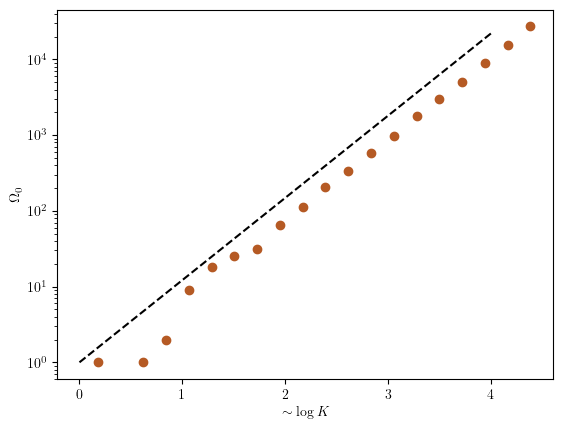

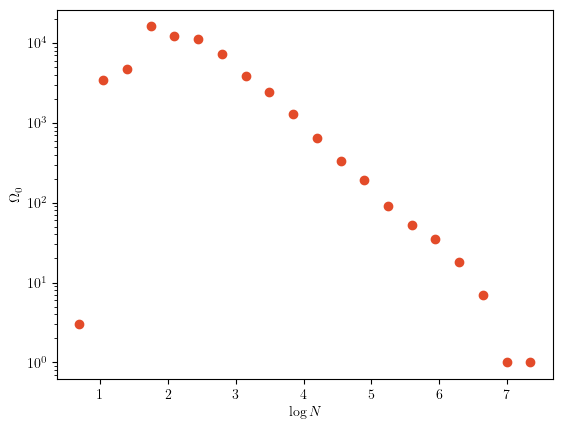

1.3 2.6


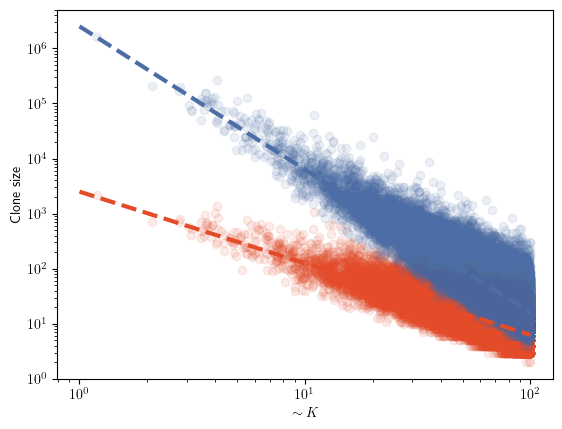

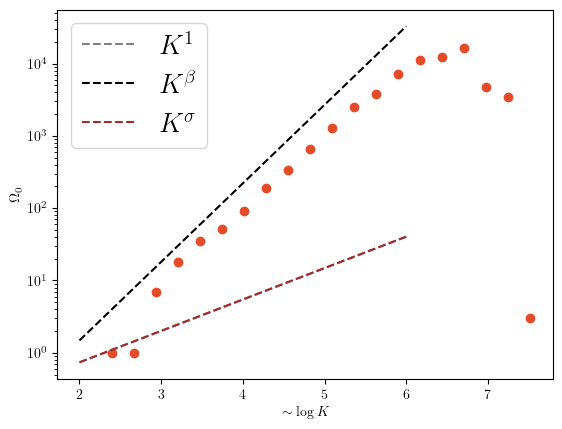

In [10]:
fig, ax = plt.subplots()
# ax.hist(1/np.array(E1), alpha=0.7, bins = np.logspace(1, 3, 30), density=False)
p_K_primary, Ks_primary = np.histogram(np.log(np.array(np.array(K1))), bins = 20, density=False)
ax.scatter(Ks_primary[:-1], p_K_primary, marker='o', color=my_brown)
ax.plot(np.linspace(0, 4, 30), 1e0*np.exp((np.linspace(0, 4, 30))*(beta)), color = 'k', linestyle = '--', label = r'$u^{-\beta}$')
# my_plot_layout(ax=ax)
ax.set_xlabel(r'$\sim \log K$')
ax.set_ylabel(r'$\Omega_0$')
ax.set_yscale('log')
# ax.set_xscale('log')
# ax.set_title(f'N0={N0}, u0={u0}, lambda_A={lambda_A}, lambda_B={lambda_B}')
# ax.legend(fontsize=20)
plt.show();


fig, ax = plt.subplots()
# ax.hist(1/np.array(E1), alpha=0.7, bins = np.logspace(1, 3, 30), density=False)
p_N_primary, Ns_primary = np.histogram(np.log((np.array(CS1))), bins = 20, density=False)
ax.scatter(Ns_primary[:-1], p_N_primary, marker='o', color=my_red)
ax.set_xlabel(r'$\log N$')
ax.set_ylabel(r'$\Omega_0$')
ax.set_yscale('log')
# ax.set_xscale('log')
# ax.set_title(f'N0={N0}, u0={u0}, lambda_A={lambda_A}, lambda_B={lambda_B}')
# ax.legend(fontsize=20)
plt.show();


alpha = sigma*(lambda_B/lambda_A + 1)
alpha2 = alpha+sigma2*(lambda_B/lambda_A+1)

print(alpha, alpha2)

fig, ax = plt.subplots()
ax.scatter(np.array(K1), CS1, alpha=0.1, color = my_red)
ax.scatter(np.array(K1), CS2, alpha=0.1, color = my_blue)
ax.plot(np.logspace(0, 2, 30), 5e4*(np.logspace(1, 3, 30)**(-alpha)), color = my_red, linestyle = '--', lw = 3)
ax.plot(np.logspace(0, 2, 30), 1e9*(np.logspace(1, 3, 30)**(-alpha2)), color = my_blue, linestyle = '--', lw = 3)
# my_plot_layout(ax=ax)
ax.set_xlabel(r'$\sim K$')
ax.set_ylabel('Clone size')
ax.set_yscale('log')
ax.set_xscale('log')
# ax.set_title(f'N0={N0}, u0={u0}, lambda_A={lambda_A}, lambda_B={lambda_B}')
plt.show()


fig, ax = plt.subplots()
p_K_primary_inferred, Ks_primary_inferred = np.histogram(np.log((np.array(CS1)/5e4)**(-1/alpha)), bins = 20, density=False)
ax.scatter((Ks_primary_inferred[:-1]), p_K_primary_inferred, marker='o', color=my_red)
ax.plot(np.linspace(2, 6, 30), 1e-1*np.exp((np.linspace(2, 6, 30))*(1)), color = 'grey', linestyle = '--', label = r'$K^{1}$')
ax.plot(np.linspace(2, 6, 30), 1e-2*np.exp((np.linspace(2, 6, 30))*(beta)), color = 'k', linestyle = '--', label = r'$K^{\beta}$')
ax.plot(np.linspace(2, 6, 30), 1e-1*np.exp((np.linspace(2, 6, 30))*(sigma)), color = 'brown', linestyle = '--', label = r'$K^{\sigma}$')
# ax.plot(np.linspace(5, 7, 30), 8e5*np.exp((np.linspace(5, 7, 30))*(-1)), color = 'k', linestyle = '--')
# my_plot_layout(ax=ax)
ax.set_xlabel(r'$\sim \log K$')
ax.set_ylabel(r'$\Omega_0$')
ax.set_yscale('log')
# ax.set_xscale('log')
# ax.set_title(f'N0={N0}, u0={u0}, lambda_A={lambda_A}, lambda_B={lambda_B}')
ax.legend(fontsize=20)
plt.show();

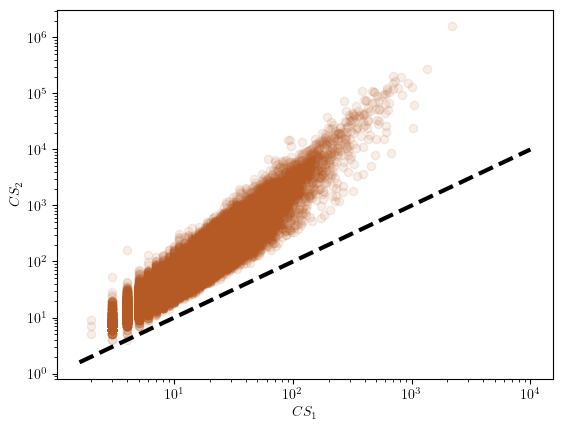

In [11]:
fig, ax = plt.subplots()
ax.scatter(CS1, CS2, alpha=0.1, color = my_brown)
# ax.plot(np.logspace(1.2, 2.5, 30), 1e1*(np.logspace(1.2, 2.5, 30)**(1)), color = my_brown, linestyle = '--', lw = 3)
ax.plot(np.logspace(0.2, 4, 30), np.logspace(0.2, 4, 30)**(1), color = 'k', linestyle = '--', lw = 3)
# my_plot_layout(ax=ax)
ax.set_xlabel(r'$CS_1$')
ax.set_ylabel(r'$CS_2$')
ax.set_yscale('log')
ax.set_xscale('log')
# ax.set_title(f'N0={N0}, u0={u0}, lambda_A={lambda_A}, lambda_B={lambda_B}')
plt.show()

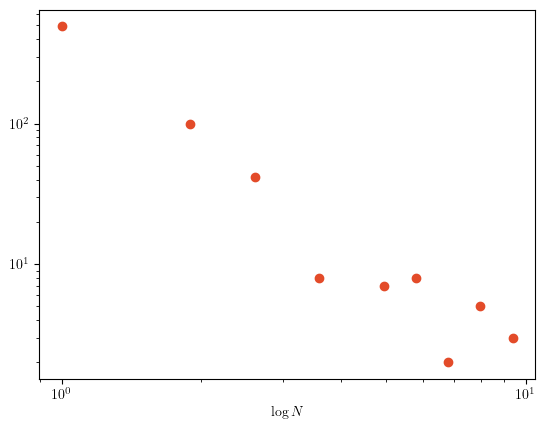

/var/folders/zb/94w9fjpd0_s_68nft_zfybt80000gp/T/ipykernel_87781/1341018411.py:23: RuntimeWarning: divide by zero encountered in log
  y_array = np.log(p_K_primary_data)


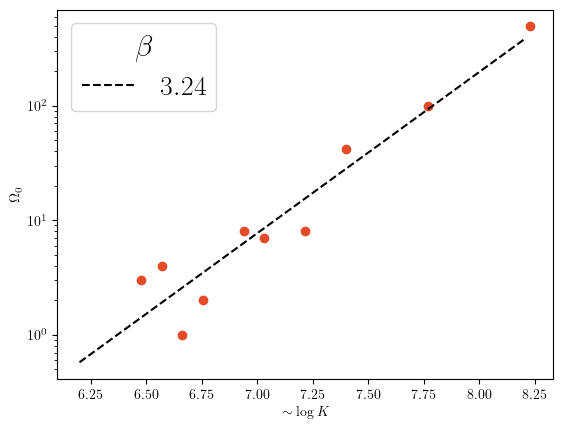

In [12]:
fig, ax = plt.subplots()
p_N_primary_data, Ns_primary_data = np.histogram(np.log((np.array(CS_primary))), bins = 15, density = False)
dNs = Ns_primary_data[1] - Ns_primary_data[0]
ax.scatter(np.exp(Ns_primary_data[:-1]), p_N_primary_data, marker='o', color=my_red)
# ax.plot(np.linspace(2, 6, 30), 2e-1*np.exp((np.linspace(2, 6, 30))*(1)), color = 'grey', linestyle = '--', label = r'$u^{-\beta}$')
# ax.plot(np.linspace(2, 6, 30), 2e-2*np.exp((np.linspace(2, 6, 30))*(beta)), color = 'k', linestyle = '--', label = r'$u^{-\beta}$')
# ax.plot(np.linspace(5, 7, 30), 8e5*np.exp((np.linspace(5, 7, 30))*(-1)), color = 'k', linestyle = '--', label = r'$u^{-\beta}$')
# my_plot_layout(ax=ax)
ax.set_xlabel(r'$\log N$')
# ax.set_ylabel(r'$\Omega_0$')
ax.set_yscale('log')
ax.set_xscale('log')
# ax.set_title(f'N0={N0}, u0={u0}, lambda_A={lambda_A}, lambda_B={lambda_B}')
# ax.legend(fontsize=20)
plt.show();

fig, ax = plt.subplots()
# ax.hist(1/np.array(E1), alpha=0.7, bins = np.logspace(1, 3, 30), density=False)
# print(((np.array(CS_primary))))
p_K_primary_data, Ks_primary_data = np.histogram(np.log((np.array(CS_primary)/5e4)**(-1/alpha)), bins = 20, density=False)
ax.scatter((Ks_primary_data[:-1]), p_K_primary_data, marker='o', color=my_red)
x_array = Ks_primary_data[:-1]
y_array = np.log(p_K_primary_data)
x_array = x_array[~np.isinf(y_array)]
y_array = y_array[~np.isinf(y_array)]
popt, pcov = curve_fit(my_linear_func, x_array, y_array)
ax.plot(np.linspace(6.2, 8.2, 30), np.exp(popt[0])*np.exp((np.linspace(6.2, 8.2, 30))*(popt[1])), color = 'k', linestyle = '--', label = r'$%.2f$'%popt[1])
# my_plot_layout(ax=ax)
ax.set_xlabel(r'$\sim \log K$')
ax.set_ylabel(r'$\Omega_0$')
ax.set_yscale('log')
# ax.set_xscale('log')
# ax.set_title(f'N0={N0}, u0={u0}, lambda_A={lambda_A}, lambda_B={lambda_B}')
ax.legend(fontsize=20, title = r'$\beta$', title_fontsize = 22)
plt.show();

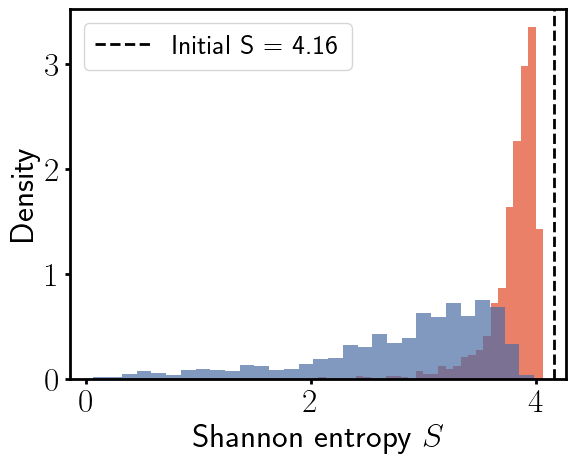

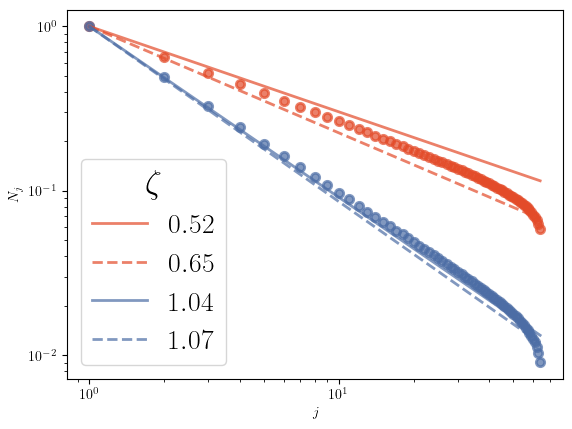

In [13]:
fig, ax = plt.subplots()
ax.hist(S01, bins=30, density=True, alpha=0.7, color = my_red)
ax.hist(S02, bins=30, density=True, alpha=0.7, color = my_blue)
ax.axvline(S0, color='k', linestyle='--', linewidth=2, label=f'Initial S = {S0:.2f}')
# plot a vertical dashed line showing the initial entropy
my_plot_layout(ax=ax)
ax.set_xlabel('Shannon entropy $S$')
ax.set_ylabel('Density')
# ax.set_title(f'N0={N0}, u0={u0}, lambda_A={lambda_A}, lambda_B={lambda_B}')
ax.legend(fontsize=20)
plt.show()

fig, ax = plt.subplots()
# zeta = lambda_B*sigma/(lambda_A*(beta))
# zeta2 = zeta*(sigma2/sigma + 1)
zeta = alpha/(beta)
zeta2 = alpha2/(beta)
ax.scatter(np.arange(1, N0+1), final_Nb1[:N0], alpha=0.7, color = my_red, lw = 2)
ax.plot(np.arange(1, N0+1), np.arange(1, N0+1)**(-zeta), alpha=0.7, color = my_red, lw = 2, ls = '-', label = r'$%.2f$' % zeta)
x_array1 = np.log(np.arange(1, N0+1))
y_array1 = np.log(final_Nb1[:N0])
popt1, pcov1 = curve_fit(my_linear_func, x_array1, y_array1)
ax.plot(np.arange(1, N0+1), np.arange(1, N0+1)**(popt1[1]), alpha=0.7, color = my_red, lw = 2, ls = '--', label = r'$%.2f$'%-popt1[1])

ax.scatter(np.arange(1, N0+1), final_Nb2[:N0], alpha=0.7, color = my_blue, lw = 2)
ax.plot(np.arange(1, N0+1), np.arange(1, N0+1)**(-zeta2), alpha=0.7, color = my_blue, lw = 2, ls = '-', label = r'$%.2f$' % zeta2)
x_array2 = np.log(np.arange(1, N0+1))
y_array2 = np.log(final_Nb2[:N0])
popt2, pcov2 = curve_fit(my_linear_func, x_array2, y_array2)
ax.plot(np.arange(1, N0+1), np.arange(1, N0+1)**(popt2[1]), alpha=0.7, color = my_blue, lw = 2, ls = '--', label = r'$%.2f$'%-popt2[1])
# my_plot_layout(ax=ax)
ax.set_xlabel(r'$j$')
ax.set_ylabel(r'$N_j$')
ax.set_yscale('log')
ax.set_xscale('log')
# ax.set_title(f'N0={N0}, u0={u0}, lambda_A={lambda_A}, lambda_B={lambda_B}')
ax.legend(fontsize=20, title = r'$\zeta$', title_fontsize = 24)
plt.show();

3.974330777237957 3.4217360395048333


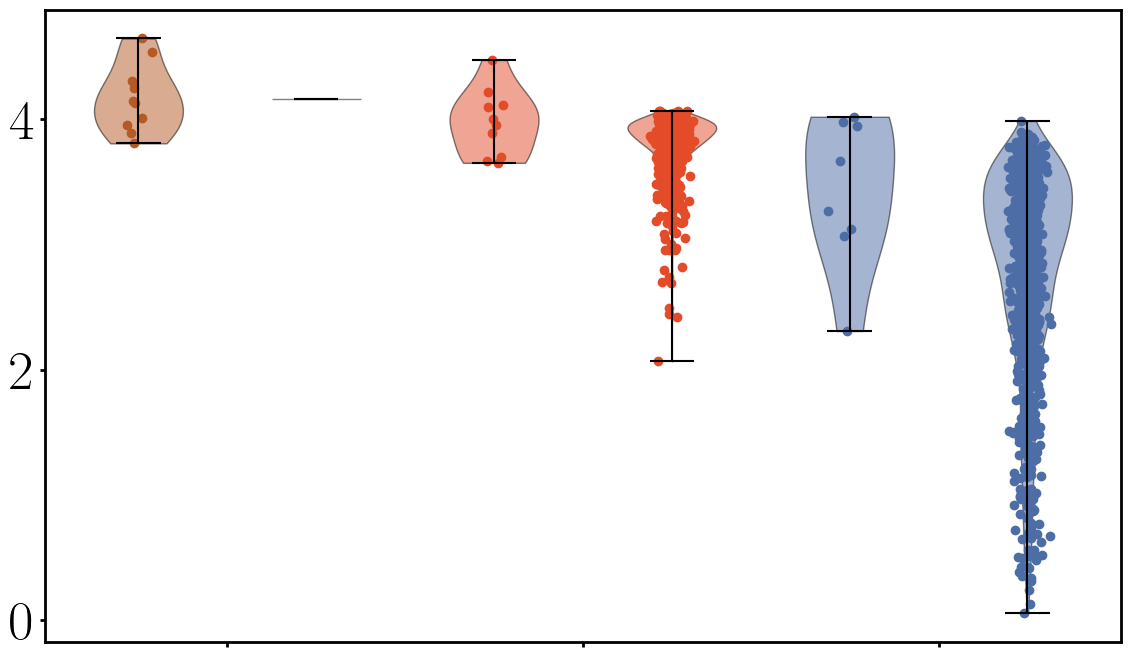

In [16]:
colors = [my_brown, my_red, my_blue]
colors0 = [my_brown, my_red, my_blue]
fig, ax = plt.subplots(figsize=(8*1.62,8), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})

# DATA
print(np.mean(S_primary), np.mean(S_memory))
parts = ax.violinplot([(S01_data), (S_primary), (S_memory)], positions= [0., 2., 4.], widths=.5)
for i, body in enumerate(parts['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
parts['cbars'].set_color('black')
parts['cmins'].set_color('black')
parts['cmaxes'].set_color('black')
# Jittered scatter
ax.scatter(np.random.normal(0, 0.04, len(S01_data)), (S01_data), color = my_brown)
ax.scatter(np.random.normal(2, 0.04, len(S_primary)), (S_primary), color = my_red)
ax.scatter(np.random.normal(4, 0.04, len(S_memory)), (S_memory), color = my_blue)

# SIMULATIONS
parts0 = ax.violinplot([(S0), (S01), (S02)], positions= [1, 3, 5], widths=0.5)
for i, body in enumerate(parts0['bodies']):
    body.set_facecolor(colors0[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
parts0['cbars'].set_color('black')
parts0['cmins'].set_color('black')
parts0['cmaxes'].set_color('black')
# Jittered scatter
# ax.scatter(np.random.normal(1, 0.04, len(S0)), (S0/S0), color = my_brown)
ax.scatter(np.random.normal(3, 0.04, len(S01)), (S01), color = my_red)
ax.scatter(np.random.normal(5, 0.04, len(S02)), (S02), color = my_blue)

my_plot_layout(ax =ax, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30 ) 
# ax.set_ylabel(r'Shannon entropy $S$', fontsize = 20)
ax.set_xticks([0.5, 2.5, 4.5], ['', '', '']);
fig.savefig(output_plot + 'entropy_violinplot0.pdf')

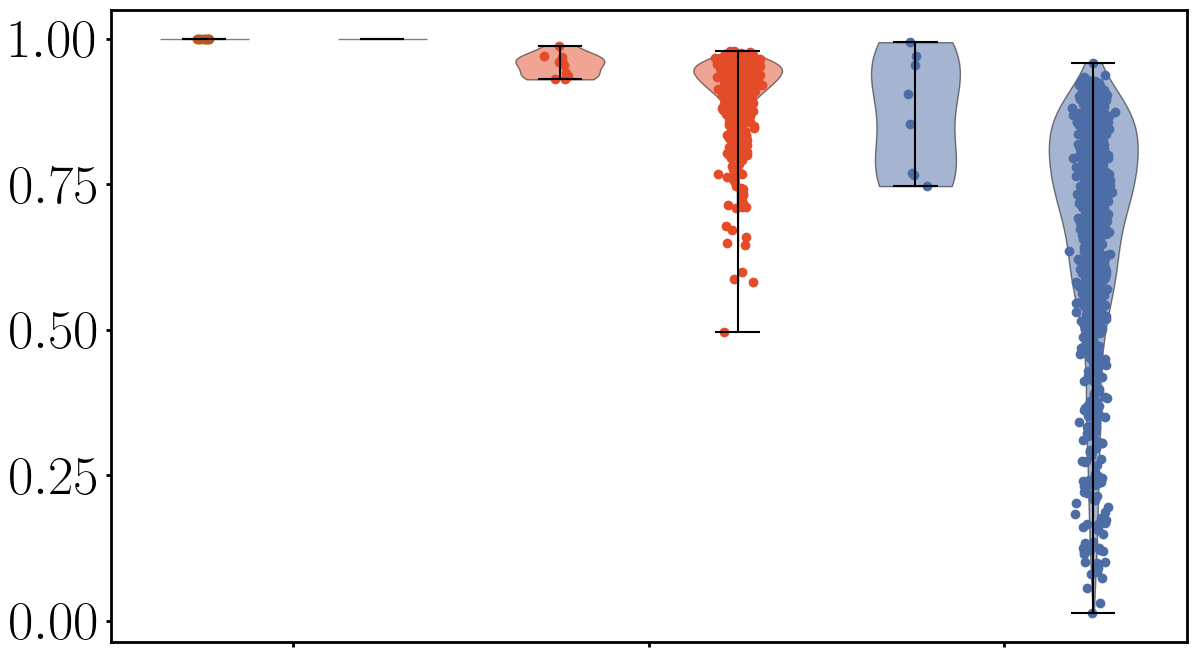

In [15]:
colors = [my_brown, my_red, my_blue]
colors0 = [my_brown, my_red, my_blue]
fig, ax = plt.subplots(figsize=(8*1.62,8), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})

# DATA
parts = ax.violinplot([(S01_data/S01_data), (S_primary/S01_data), (S_memory/S02_data)], positions= [0., 2., 4.], widths=.5)
for i, body in enumerate(parts['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
parts['cbars'].set_color('black')
parts['cmins'].set_color('black')
parts['cmaxes'].set_color('black')
# Jittered scatter
ax.scatter(np.random.normal(0, 0.04, len(S01_data)), (S01_data/S01_data), color = my_brown)
ax.scatter(np.random.normal(2, 0.04, len(S_primary)), (S_primary/S01_data), color = my_red)
ax.scatter(np.random.normal(4, 0.04, len(S_memory)), (S_memory/S02_data), color = my_blue)

# SIMULATIONS
parts0 = ax.violinplot([(S0/S0), (S01/S0), (S02/S0)], positions= [1, 3, 5], widths=0.5)
for i, body in enumerate(parts0['bodies']):
    body.set_facecolor(colors0[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
parts0['cbars'].set_color('black')
parts0['cmins'].set_color('black')
parts0['cmaxes'].set_color('black')
# Jittered scatter
# ax.scatter(np.random.normal(1, 0.04, len(S0)), (S0/S0), color = my_brown)
ax.scatter(np.random.normal(3, 0.04, len(S01)), (S01/S0), color = my_red)
ax.scatter(np.random.normal(5, 0.04, len(S02)), (S02/S0), color = my_blue)

my_plot_layout(ax =ax, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30 ) 
# ax.set_ylabel(r'Shannon entropy $S$', fontsize = 20)
ax.set_xticks([0.5, 2.5, 4.5], ['', '', '']);
fig.savefig(output_plot + 'entropy_violinplot.pdf')